# Hybrid Quantum-Classical ML for Early Parkinson's Detection (Voice)
### SIH26139 — Mobile-only screening pipeline

This notebook builds and compares **four** models on voice-derived features:

1. **Classical NN** (baseline, full precision)
2. **Classical NN — Quantized (INT8)** (mobile-deployable version)
3. **Hybrid Quantum-Classical NN (VQC)** (full precision)
4. **Hybrid Quantum-Classical NN — Quantized classical layers** (mobile-deployable version)
5. *(Bonus)* Quantum Kernel SVM (qSVM) for reference

Each model is evaluated on: **Accuracy, Sensitivity, Specificity, Precision, F1, AUC, model size (KB), and inference latency (ms)** — the exact numbers you need to justify (or question) on-device quantum-hybrid deployment for a mobile app.

## 1. Setup

In [20]:
!pip install -q librosa praat-parselmouth pennylane torch scikit-learn xgboost matplotlib seaborn pandas

In [21]:
import os
import time
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                      StratifiedKFold, StratifiedGroupKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("Torch:", torch.__version__)

cuda
Torch: 2.10.0+cu128


## 2. Configuration

In [22]:
DATA_DIR = "/kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset"

SAMPLE_RATE = 16000
N_MFCC = 13
N_QUBITS = 8
N_SELECTED_FEATURES = N_QUBITS
TEST_SIZE = 0.2

# Actual dataset structure
VOICE_DATA_DIR = os.path.join(DATA_DIR, "Voice_Dataset")
HEALTHY_DIR = os.path.join(VOICE_DATA_DIR, "Healthy")
PARKINSONS_DIR = os.path.join(VOICE_DATA_DIR, "Parkinsons")

# Check whether real dataset exists
USE_REAL_DATA = (
    os.path.isdir(HEALTHY_DIR)
    and os.path.isdir(PARKINSONS_DIR)
)

print("DATA_DIR:", DATA_DIR)
print("VOICE_DATA_DIR:", VOICE_DATA_DIR)
print("Healthy:", HEALTHY_DIR)
print("Parkinsons:", PARKINSONS_DIR)
print("Real dataset found:", USE_REAL_DATA)

if USE_REAL_DATA:
    print("Healthy files:", len(os.listdir(HEALTHY_DIR)))
    print("Parkinsons files:", len(os.listdir(PARKINSONS_DIR)))

DATA_DIR: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset
VOICE_DATA_DIR: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset
Healthy: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset/Healthy
Parkinsons: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset/Parkinsons
Real dataset found: True
Healthy files: 574
Parkinsons files: 560


## 3. Feature Extraction (raw audio -> voice biomarkers)

In [23]:
import librosa

def extract_librosa_features(y, sr):
    """MFCCs, F0, ZCR, spectral features -- classical acoustic features."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
    f0 = f0[~np.isnan(f0)]
    f0_mean = np.mean(f0) if len(f0) else 0.0
    f0_std = np.std(f0) if len(f0) else 0.0

    zcr = librosa.feature.zero_crossing_rate(y).mean()
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()

    feats = {}
    for i, v in enumerate(mfcc_mean):
        feats[f"mfcc_mean_{i}"] = v
    for i, v in enumerate(mfcc_std):
        feats[f"mfcc_std_{i}"] = v
    feats.update({
        "f0_mean": f0_mean, "f0_std": f0_std,
        "zcr": zcr, "spec_centroid": spec_centroid, "spec_rolloff": spec_rolloff
    })
    return feats


def extract_praat_features(wav_path):
    """Jitter, shimmer, HNR -- the classic dysphonia measures used in PD voice literature.
    Requires praat-parselmouth. Falls back to NaNs (dropped later) if it fails on a file."""
    try:
        import parselmouth
        from parselmouth.praat import call

        snd = parselmouth.Sound(wav_path)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

        jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_rap   = call(point_process, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_ppq5  = call(point_process, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)

        shimmer_local = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq3  = call([snd, point_process], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq5  = call([snd, point_process], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)

        return {
            "jitter_local": jitter_local, "jitter_rap": jitter_rap, "jitter_ppq5": jitter_ppq5,
            "shimmer_local": shimmer_local, "shimmer_apq3": shimmer_apq3, "shimmer_apq5": shimmer_apq5,
            "hnr": hnr,
        }
    except Exception as e:
        return {
            "jitter_local": np.nan, "jitter_rap": np.nan, "jitter_ppq5": np.nan,
            "shimmer_local": np.nan, "shimmer_apq3": np.nan, "shimmer_apq5": np.nan,
            "hnr": np.nan,
        }


def extract_all_features(wav_path):
    y, sr = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    y, _ = librosa.effects.trim(y, top_db=25)          # trim silence
    feats = extract_librosa_features(y, sr)
    feats.update(extract_praat_features(wav_path))
    return feats

## 4. Build the Dataset

In [24]:
# 4. Build the Dataset

DATA_ROOT = "/kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset"
DATA_DIR = os.path.join(DATA_ROOT, "Voice_Dataset")

SAMPLE_RATE = 16000
N_MFCC = 13
N_QUBITS = 8
N_SELECTED_FEATURES = N_QUBITS
TEST_SIZE = 0.2

HEALTHY_DIR = os.path.join(DATA_DIR, "Healthy")
PARKINSONS_DIR = os.path.join(DATA_DIR, "Parkinsons")


# Check real dataset


USE_REAL_DATA = (
    os.path.isdir(HEALTHY_DIR)
    and os.path.isdir(PARKINSONS_DIR)
)

print("DATA_DIR:", DATA_DIR)
print("Healthy directory:", HEALTHY_DIR)
print("Parkinsons directory:", PARKINSONS_DIR)

if USE_REAL_DATA:
    healthy_files = glob.glob(os.path.join(HEALTHY_DIR, "*.wav"))
    parkinsons_files = glob.glob(os.path.join(PARKINSONS_DIR, "*.wav"))

    print(f"Healthy: {len(healthy_files)} WAV files")
    print(f"Parkinsons: {len(parkinsons_files)} WAV files")
else:
    print("Real dataset not found.")



# Subject ID


def get_subject_id(filename):
    """
    Extract an ID from filenames such as:

        healthy_563.wav
        parkinsons_111.wav

    If no ID can be extracted, use the filename itself.
    """

    stem = os.path.splitext(os.path.basename(filename))[0]

    match = re.search(r"_(\d+)$", stem)

    if match:
        return match.group(1)

    return stem



# Load real audio dataset


def load_real_dataset(data_dir):

    rows = []

    class_mapping = {
        "Healthy": 0,
        "Parkinsons": 1
    }

    for folder, label in class_mapping.items():

        folder_path = os.path.join(data_dir, folder)

        wav_files = glob.glob(
            os.path.join(folder_path, "*.wav")
        )

        print(f"\n{folder}: {len(wav_files)} WAV files")

        for i, wav_path in enumerate(wav_files, start=1):

            try:

                # Extract acoustic + Praat features
                feats = extract_all_features(wav_path)

                if feats is None:
                    print(
                        f"WARNING: No features returned for "
                        f"{os.path.basename(wav_path)}"
                    )
                    continue

                feats["label"] = label
                feats["file"] = os.path.basename(wav_path)

                rows.append(feats)

                if i % 50 == 0:
                    print(
                        f"  Processed {i}/{len(wav_files)}"
                    )

            except Exception as e:

                print(
                    f"ERROR processing "
                    f"{os.path.basename(wav_path)}: "
                    f"{type(e).__name__}: {e}"
                )

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.DataFrame(rows)



# Build dataframe


if USE_REAL_DATA:

    print(
        "\nFound REAL Parkinson's voice dataset."
    )

    print(
        "Extracting audio features. "
        "This may take several minutes..."
    )

    df = load_real_dataset(DATA_DIR)

else:

    print(
        "\nWARNING: Real dataset not found."
    )

    print(
        "Using synthetic data. "
        "DO NOT use synthetic metrics in your report."
    )

    df = make_synthetic_dataset()



# Safety checks


if df.empty:

    raise RuntimeError(
        "\nNo samples were successfully loaded.\n"
        "The audio files were found, but feature extraction "
        "returned no usable samples.\n"
        "Check the extract_all_features() function."
    )

if "file" not in df.columns:

    raise RuntimeError(
        "Dataset was loaded but the 'file' column is missing."
    )

if "label" not in df.columns:

    raise RuntimeError(
        "Dataset was loaded but the 'label' column is missing."
    )



# Subject IDs


df["subject_id"] = df["file"].apply(get_subject_id)



# Remove invalid feature rows


feature_cols = [
    c for c in df.columns
    if c not in ("label", "file", "subject_id")
]

df = df.dropna(
    subset=feature_cols
).reset_index(drop=True)



# Final dataset information


print("\n" + "_" * 60)
print("DATASET READY")
print("_" * 60)

print("Shape:", df.shape)

print(
    "Number of recordings:",
    len(df)
)

print(
    "Number of unique IDs:",
    df["subject_id"].nunique()
)

print("\nClass distribution:")
print(
    df["label"].value_counts()
)

print("\nClass names:")
print(
    df["label"]
    .map({0: "Healthy", 1: "Parkinsons"})
    .value_counts()
)

print("\nFeature count:", len(feature_cols))

print("\nFirst 5 rows:")
display(df.head())

DATA_DIR: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset
Healthy directory: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset/Healthy
Parkinsons directory: /kaggle/input/datasets/ucimachinelearning/parkinsons-voice-dataset/Voice_Dataset/Parkinsons
Healthy: 574 WAV files
Parkinsons: 560 WAV files

Found REAL Parkinson's voice dataset.
Extracting audio features. This may take several minutes...

Healthy: 574 WAV files
  Processed 50/574
  Processed 100/574
  Processed 150/574
  Processed 200/574
  Processed 250/574
  Processed 300/574
  Processed 350/574
  Processed 400/574
  Processed 450/574
  Processed 500/574
  Processed 550/574

Parkinsons: 560 WAV files
  Processed 50/560
  Processed 100/560
  Processed 150/560
  Processed 200/560
  Processed 250/560
  Processed 300/560
  Processed 350/560
  Processed 400/560
  Processed 450/560
  Processed 500/560
  Processed 550/560

_________________________________________________

,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,...,jitter_local,jitter_rap,jitter_ppq5,shimmer_local,shimmer_apq3,shimmer_apq5,hnr,label,file,subject_id
0,-224.368317,173.529663,-53.113224,15.105078,-21.865664,-41.443707,34.218689,-0.760222,-13.832991,17.332458,...,0.003105,0.001757,0.001958,0.042929,0.020237,0.025800,21.359329,0,healthy_563.wav,563
1,-199.501389,182.125717,-74.392410,7.646266,-22.021597,-15.275163,23.601358,-25.179708,-3.361056,1.602966,...,0.003971,0.002237,0.002183,0.038946,0.019333,0.024157,22.059966,0,healthy_307.wav,307
2,-145.265488,190.912567,-116.015114,-0.012650,-37.900398,-22.616770,23.935453,-35.927208,4.470317,8.990859,...,0.004138,0.002028,0.002163,0.038810,0.021972,0.026096,20.302171,0,healthy_002.wav,002
3,-147.321716,214.619659,-97.360260,-19.325165,-44.828468,-24.346943,23.337023,-30.437002,-10.243678,6.782962,...,0.013093,0.006097,0.006976,0.126031,0.064711,0.073953,10.653290,0,healthy_464.wav,464
4,-209.435181,178.416901,-82.264542,0.530346,-22.930338,-8.280055,20.780298,-34.161125,6.653492,13.294046,...,0.003147,0.001757,0.001990,0.069960,0.025936,0.034925,18.082121,0,healthy_111.wav,111


## 5. Train / Validation / Test Split + Scaling

A proper **3-way split** matters here: the validation set is used for early stopping (deciding when to stop training / which epoch's weights to keep), while the **test set is never touched until final evaluation**. Using the test set itself for early stopping (a common shortcut) leaks test information into model selection and makes your reported metrics optimistic.

574 unique subjects across 1134 recordings -> using GROUP-AWARE splitting.
Split sizes -> train: 683  val: 225  test: 226
Top 8 features selected for the quantum circuit (train-only):
['mfcc_std_1', 'mfcc_mean_1', 'mfcc_std_3', 'mfcc_std_0', 'mfcc_std_10', 'mfcc_std_2', 'mfcc_std_11', 'f0_mean']


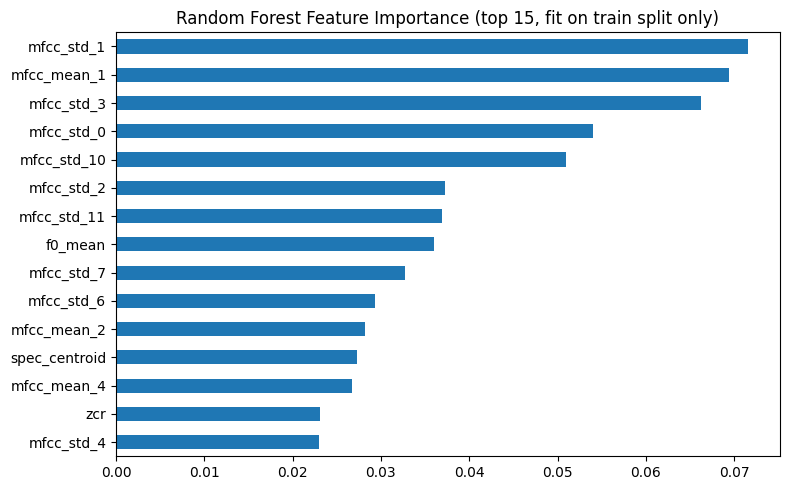

In [25]:
## 5. Train/Val/Test Split, THEN Feature Selection (fit only on training data)

feature_cols = [c for c in df.columns if c not in ("label", "file", "subject_id")]
X_full = df[feature_cols].values
y = df["label"].values
groups_full = df["subject_id"].values

# --- Split FIRST, before anything touches the data ---
# Group-aware whenever a subject has more than one recording, so a subject's voice
# never appears in more than one of train/val/test (plain random splitting would leak
# subject identity across the split and inflate every metric downstream).
n_subjects = df["subject_id"].nunique()
use_group_split = n_subjects < len(df) and n_subjects >= 6  # need enough groups to split/stratify sensibly

if use_group_split:
    print(f"{n_subjects} unique subjects across {len(df)} recordings -> using GROUP-AWARE splitting.")
    gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_full_idx, test_idx = next(gss1.split(X_full, y, groups=groups_full))

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
    tr_rel, va_rel = next(gss2.split(X_full[train_full_idx], y[train_full_idx],
                                      groups=groups_full[train_full_idx]))
    train_idx, val_idx = train_full_idx[tr_rel], train_full_idx[va_rel]
    # Note: GroupShuffleSplit splits by group only, not by label -- with very few
    # subjects the class balance below can come out uneven; check it before trusting CV.
else:
    print(f"{n_subjects} unique subjects across {len(df)} recordings -> one recording per "
          f"subject (or too few subjects to group-split), using standard stratified splitting.")
    train_full_idx, test_idx = train_test_split(
        np.arange(len(X_full)), test_size=TEST_SIZE, random_state=SEED, stratify=y
    )
    train_idx, val_idx = train_test_split(
        train_full_idx, test_size=0.25, random_state=SEED, stratify=y[train_full_idx]
    )  # 0.25 of the remaining 80% = 20% of the original data

X_train_all, y_train = X_full[train_idx], y[train_idx]
X_val_all,   y_val   = X_full[val_idx],   y[val_idx]
X_test_all,  y_test  = X_full[test_idx],  y[test_idx]

print("Split sizes -> train:", len(train_idx), " val:", len(val_idx), " test:", len(test_idx))

# --- Feature selection: fit ONLY on the training split ---
rf_selector = RandomForestClassifier(n_estimators=300, random_state=SEED)
rf_selector.fit(X_train_all, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(N_SELECTED_FEATURES).index.tolist()

print("Top", N_SELECTED_FEATURES, "features selected for the quantum circuit (train-only):")
print(top_features)

plt.figure(figsize=(8, 5))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (top 15, fit on train split only)")
plt.tight_layout()
plt.show()

# --- Now subset every split down to the selected columns ---
feature_idx = [feature_cols.index(f) for f in top_features]
X_train = X_train_all[:, feature_idx]
X_val   = X_val_all[:, feature_idx]
X_test  = X_test_all[:, feature_idx]

# Kept for the Section 17 CV cell: full feature-selected data + subject groups.
# NOTE: rf_selector/top_features were fit on this split's training rows, so reusing
# them inside every CV fold below is a deliberate simplification -- a fully nested CV
# would redo feature selection inside each fold too. Worth flagging if you report
# these CV numbers formally.
X = X_full[:, feature_idx]

In [26]:
## Scale features (fit only on the training split) and convert to torch tensors.
## This step was missing before -- every training/eval cell downstream depends on
## scaler / X_train_t / X_val_t / X_test_t / y_train_t / y_val_t existing.

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
# y_train / y_val / y_test stay as plain numpy arrays too -- evaluate(), roc_curve()
# and the confusion-matrix-based metrics all expect numpy labels, not tensors.

print("Train:", X_train_t.shape, " Val:", X_val_t.shape, " Test:", X_test_t.shape)
print("Class balance -> train:", np.bincount(y_train.astype(int)),
      " val:", np.bincount(y_val.astype(int)),
      " test:", np.bincount(y_test.astype(int)))

Train: torch.Size([683, 8])  Val: torch.Size([225, 8])  Test: torch.Size([226, 8])
Class balance -> train: [344 339]  val: [115 110]  test: [115 111]


## 6. Scaling & Tensor Conversion

## 7. Models

### 7.1 Classical Baseline (the "normal model")

In [27]:
class ClassicalModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))

### 7.2 Hybrid Quantum-Classical Model (VQC)

In [28]:
import pennylane as qml

dev = qml.device("default.qubit", wires=N_QUBITS)
N_LAYERS = 3

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)


class HybridQuantumModel(nn.Module):
    """Classical pre-processing -> angle encoding -> quantum circuit -> classical post-processing."""
    def __init__(self, n_features, n_qubits):
        super().__init__()
        self.pre = nn.Sequential(nn.Linear(n_features, n_qubits), nn.Tanh())
        self.quantum = quantum_layer
        self.post = nn.Sequential(nn.Linear(n_qubits, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        x = self.pre(x) * np.pi          # scale Tanh output [-1,1] -> angle range
        x = self.quantum(x)
        x = self.post(x)
        return torch.sigmoid(x)

## 8. Training Utility (with early stopping)

In [29]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=0.01,
                 weight_decay=1e-4, patience=15, verbose=True):
    """Trains with early stopping on validation loss, restoring the best-epoch weights
    at the end. This is what prevents the runaway overfitting you'd otherwise see if you
    just trained for a fixed number of epochs (small dataset + no regularization = the
    model eventually memorizes the training set and validation loss climbs back up).

    Loss is class-weighted (inverse frequency) on both train and val, computed separately
    for each split. This matters most for val: an imbalanced val split would otherwise bias
    early stopping toward whichever epoch favors the majority class in val, not the epoch
    that's actually best overall."""

    def class_weights(y):
        y_flat = y.view(-1)
        classes, counts = torch.unique(y_flat, return_counts=True)
        n = y_flat.shape[0]
        w_per_class = {int(c.item()): n / (len(classes) * cnt.item()) for c, cnt in zip(classes, counts)}
        return torch.tensor([w_per_class[int(v.item())] for v in y_flat], dtype=torch.float32).view(-1, 1)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn_train = nn.BCELoss(weight=class_weights(y_train))
    loss_fn_val = nn.BCELoss(weight=class_weights(y_val))
    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train)
        loss = loss_fn_train(preds, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = loss_fn_val(val_preds, y_val)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())

        if val_loss.item() < best_val_loss - 1e-4:
            best_val_loss = val_loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:3d} | train_loss={loss.item():.4f} | val_loss={val_loss.item():.4f}"
                  f" | best_val_loss={best_val_loss:.4f} | no_improve={epochs_no_improve}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs). "
                      f"Restoring best weights (val_loss={best_val_loss:.4f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## 9. Train Classical Model

In [30]:
torch.manual_seed(SEED)
classical_model = ClassicalModel(n_features=N_SELECTED_FEATURES)
classical_history = train_model(classical_model, X_train_t, y_train_t, X_val_t, y_val_t,
                                 epochs=150, lr=0.01, weight_decay=1e-4, patience=15)

Epoch   0 | train_loss=0.7104 | val_loss=0.7027 | best_val_loss=0.7027 | no_improve=0
Epoch  10 | train_loss=0.6014 | val_loss=0.5693 | best_val_loss=0.5693 | no_improve=0
Epoch  20 | train_loss=0.4916 | val_loss=0.4486 | best_val_loss=0.4486 | no_improve=0
Epoch  30 | train_loss=0.4407 | val_loss=0.4087 | best_val_loss=0.4087 | no_improve=0
Epoch  40 | train_loss=0.3968 | val_loss=0.3589 | best_val_loss=0.3589 | no_improve=0
Epoch  50 | train_loss=0.3602 | val_loss=0.3215 | best_val_loss=0.3215 | no_improve=0
Epoch  60 | train_loss=0.3298 | val_loss=0.3007 | best_val_loss=0.3007 | no_improve=0
Epoch  70 | train_loss=0.2996 | val_loss=0.2750 | best_val_loss=0.2750 | no_improve=0
Epoch  80 | train_loss=0.2681 | val_loss=0.2412 | best_val_loss=0.2412 | no_improve=0
Epoch  90 | train_loss=0.2376 | val_loss=0.2137 | best_val_loss=0.2137 | no_improve=0
Epoch 100 | train_loss=0.2123 | val_loss=0.1955 | best_val_loss=0.1955 | no_improve=0
Epoch 110 | train_loss=0.1914 | val_loss=0.1845 | best

## 10. Train Hybrid Quantum Model

**Note:** quantum simulation is slower per epoch than the classical model -- expect this cell to take noticeably longer, especially as dataset size grows. Using the **same learning rate, regularization, and validation set** as the classical model keeps this a fair, apples-to-apples comparison rather than one model just being tuned more aggressively than the other.

In [31]:
torch.manual_seed(SEED)
hybrid_model = HybridQuantumModel(n_features=N_SELECTED_FEATURES, n_qubits=N_QUBITS)
hybrid_history = train_model(hybrid_model, X_train_t, y_train_t, X_val_t, y_val_t,
                              epochs=150, lr=0.01, weight_decay=1e-4, patience=15)

Epoch   0 | train_loss=0.7027 | val_loss=0.6996 | best_val_loss=0.6996 | no_improve=0
Epoch  10 | train_loss=0.6832 | val_loss=0.6804 | best_val_loss=0.6804 | no_improve=0
Epoch  20 | train_loss=0.6564 | val_loss=0.6506 | best_val_loss=0.6506 | no_improve=0
Epoch  30 | train_loss=0.5871 | val_loss=0.5670 | best_val_loss=0.5670 | no_improve=0
Epoch  40 | train_loss=0.4640 | val_loss=0.4191 | best_val_loss=0.4191 | no_improve=0
Epoch  50 | train_loss=0.3549 | val_loss=0.3184 | best_val_loss=0.3184 | no_improve=0
Epoch  60 | train_loss=0.2786 | val_loss=0.2661 | best_val_loss=0.2661 | no_improve=0
Epoch  70 | train_loss=0.2270 | val_loss=0.2321 | best_val_loss=0.2321 | no_improve=0
Epoch  80 | train_loss=0.1845 | val_loss=0.2109 | best_val_loss=0.2109 | no_improve=0
Epoch  90 | train_loss=0.1507 | val_loss=0.1920 | best_val_loss=0.1920 | no_improve=0
Epoch 100 | train_loss=0.1214 | val_loss=0.1804 | best_val_loss=0.1804 | no_improve=0
Epoch 110 | train_loss=0.1025 | val_loss=0.1903 | best

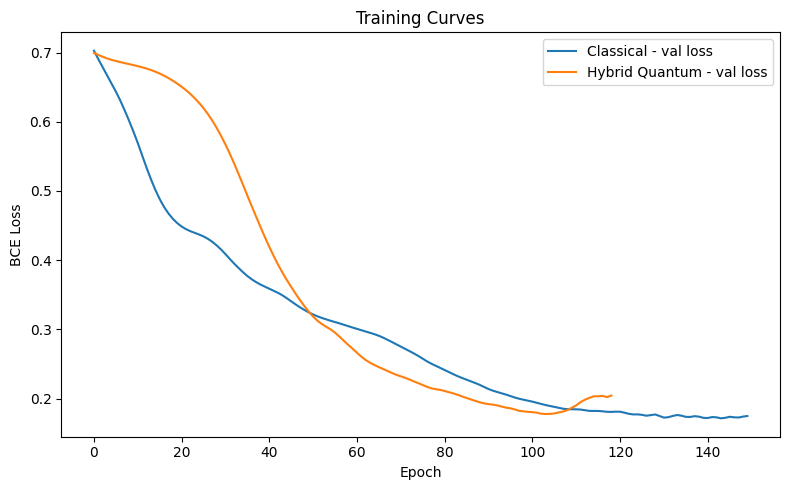

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(classical_history["val_loss"], label="Classical - val loss")
plt.plot(hybrid_history["val_loss"], label="Hybrid Quantum - val loss")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.legend(); plt.title("Training Curves")
plt.tight_layout(); plt.show()

## 11. Quantization for Mobile Deployment

**Important architectural note before you deploy:** a quantum circuit itself cannot run on a phone -- there's no on-device QPU, and simulating even 8 qubits at speed needs real compute. In practice:

- The **quantum layer runs server-side** (as a simulator call in your backend API), and the phone just sends extracted features and gets a score back, **or**
- For an **offline/on-device fallback mode**, you deploy a **quantized classical model** (either the plain classical baseline, or a classical model distilled from the hybrid quantum model's behaviour).

**INT8 dynamic quantization** below applies to the `nn.Linear` layers of both models. For the hybrid model, this quantizes its classical pre/post layers -- the quantum layer itself is left as-is (it isn't a classical tensor op, so INT8 quantization doesn't apply to it), which is exactly why the "quantized hybrid" is realistically a **server-side only** artifact, while the **quantized classical model is the one that's truly mobile-deployable end-to-end**. The comparison below makes this trade-off explicit with real numbers.

In [34]:
import torch.ao.quantization as tq

classical_model.eval()
hybrid_model.eval()

quantized_classical = tq.quantize_dynamic(classical_model, {nn.Linear}, dtype=torch.qint8)
quantized_hybrid = tq.quantize_dynamic(hybrid_model, {nn.Linear}, dtype=torch.qint8)

print("Quantization complete.")

Quantization complete.


## 12. Evaluation Utilities

In [35]:
def evaluate(model, X_test, y_test_np):
    model.eval()
    with torch.no_grad():
        probs = model(X_test).numpy().flatten()
    preds = (probs >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_np, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "accuracy": accuracy_score(y_test_np, preds),
        "precision": precision_score(y_test_np, preds, zero_division=0),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_test_np, preds, zero_division=0),
        "auc": roc_auc_score(y_test_np, probs) if len(set(y_test_np)) > 1 else float("nan"),
    }, probs


def get_model_size_kb(model, path="_temp_model.pt"):
    torch.save(model.state_dict(), path)
    size_kb = os.path.getsize(path) / 1024
    os.remove(path)
    return size_kb


def measure_latency_ms(model, sample_input, n_runs=100):
    model.eval()
    single = sample_input[:1]
    # warm-up
    with torch.no_grad():
        for _ in range(5):
            _ = model(single)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(single)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))

## 13. Run Full Comparison

In [36]:
results = []
roc_data = {}

models_to_eval = {
    "Classical (FP32)": classical_model,
    "Classical (Quantized INT8)": quantized_classical,
    "Hybrid Quantum (FP32)": hybrid_model,
    "Hybrid Quantum (Quantized classical layers)": quantized_hybrid,
}

for name, model in models_to_eval.items():
    metrics, probs = evaluate(model, X_test_t, y_test)
    size_kb = get_model_size_kb(model)
    lat_mean, lat_std = measure_latency_ms(model, X_test_t)

    row = {"model": name, "size_kb": round(size_kb, 2),
           "latency_ms_mean": round(lat_mean, 3), "latency_ms_std": round(lat_std, 3)}
    row.update({k: round(v, 4) for k, v in metrics.items()})
    results.append(row)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_data[name] = (fpr, tpr, metrics["auc"])

results_df = pd.DataFrame(results)
results_df

,model,size_kb,latency_ms_mean,latency_ms_std,accuracy,precision,sensitivity_recall,specificity,f1,auc
0,Classical (FP32),4.13,0.047,0.014,0.9425,0.9455,0.9369,0.9478,0.9412,0.9763
1,Classical (Quantized INT8),5.32,0.214,0.027,0.9425,0.9537,0.9279,0.9565,0.9406,0.9763
2,Hybrid Quantum (FP32),4.32,15.625,0.523,0.9204,0.9266,0.9099,0.9304,0.9182,0.9686
3,Hybrid Quantum (Quantized classical layers),5.63,16.587,2.158,0.9336,0.9528,0.9099,0.9565,0.9309,0.9662


## 14. Bonus: Quantum Kernel SVM (qSVM) — reference comparison

Slower (O(n²) quantum circuit evaluations), so run on a small subsample for a quick demo. Not part of the mobile-deployment size/latency comparison since it's not a neural net that can be quantized the same way -- included for the Track A vs Track B benchmarking story from the architecture doc.

In [37]:
SUBSAMPLE_N = min(40, len(X_train_s))  # keep the demo fast; increase for real evaluation

rng = np.random.default_rng(SEED)
idx_train = rng.choice(len(X_train_s), size=SUBSAMPLE_N, replace=False)
idx_test = rng.choice(len(X_test_s), size=min(20, len(X_test_s)), replace=False)

# Bound features into a safe rotation-angle range before angle-encoding, the same way
# HybridQuantumModel does with Tanh*pi. Raw StandardScaler output is unbounded, and
# feeding large values straight into AngleEmbedding just wraps around every 2*pi,
# discarding information instead of encoding it.
Xk_train = np.pi * np.tanh(X_train_s[idx_train])
Xk_test  = np.pi * np.tanh(X_test_s[idx_test])
yk_train = y_train[idx_train]
yk_test  = y_test[idx_test]

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS))
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS))
    return qml.probs(wires=range(N_QUBITS))

def quantum_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]

def compute_kernel_matrix(A, B):
    return np.array([[quantum_kernel(a, b) for b in B] for a in A])

K_train = compute_kernel_matrix(Xk_train, Xk_train)
K_test = compute_kernel_matrix(Xk_test, Xk_train)

qsvm = SVC(kernel="precomputed", probability=True)
qsvm.fit(K_train, yk_train)
qsvm_preds = qsvm.predict(K_test)
qsvm_probs = qsvm.predict_proba(K_test)[:, 1]

print("qSVM accuracy on subsample:", accuracy_score(yk_test, qsvm_preds))
print("qSVM AUC on subsample:", roc_auc_score(yk_test, qsvm_probs) if len(set(yk_test)) > 1 else "n/a (single class in subsample)")

qSVM accuracy on subsample: 0.6
qSVM AUC on subsample: 0.671875


## 15. Visual Comparison

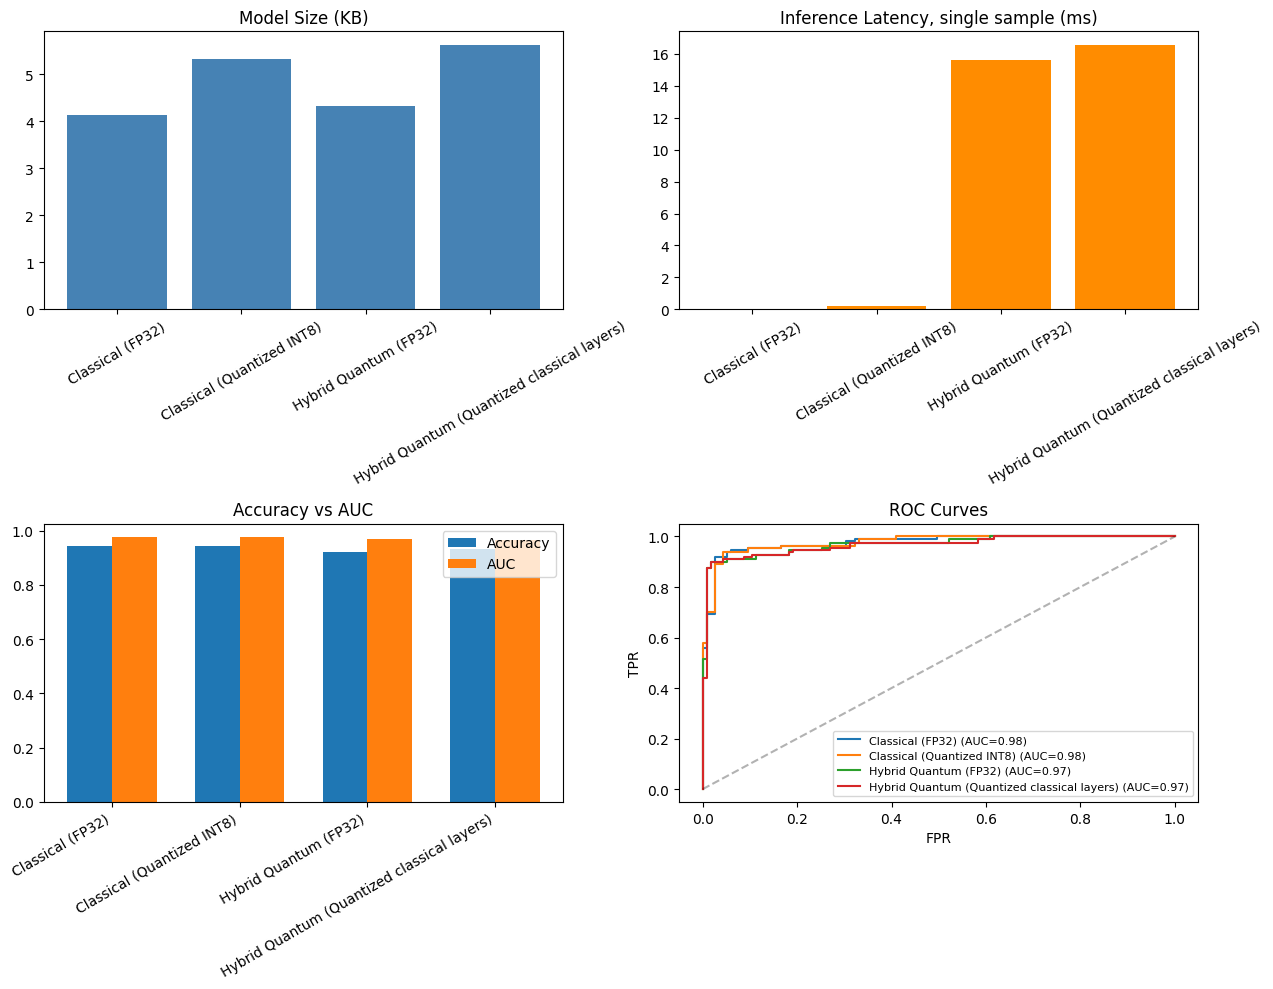

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Size
axes[0,0].bar(results_df["model"], results_df["size_kb"], color="steelblue")
axes[0,0].set_title("Model Size (KB)"); axes[0,0].tick_params(axis="x", rotation=30)

# Latency
axes[0,1].bar(results_df["model"], results_df["latency_ms_mean"], color="darkorange")
axes[0,1].set_title("Inference Latency, single sample (ms)"); axes[0,1].tick_params(axis="x", rotation=30)

# Accuracy / AUC
width = 0.35
xpos = np.arange(len(results_df))
axes[1,0].bar(xpos - width/2, results_df["accuracy"], width, label="Accuracy")
axes[1,0].bar(xpos + width/2, results_df["auc"], width, label="AUC")
axes[1,0].set_xticks(xpos); axes[1,0].set_xticklabels(results_df["model"], rotation=30, ha="right")
axes[1,0].set_title("Accuracy vs AUC"); axes[1,0].legend()

# ROC curves
for name, (fpr, tpr, auc) in roc_data.items():
    axes[1,1].plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
axes[1,1].plot([0,1],[0,1],"k--", alpha=0.3)
axes[1,1].set_title("ROC Curves"); axes[1,1].set_xlabel("FPR"); axes[1,1].set_ylabel("TPR")
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 16. How to Read These Results

- **Classical (Quantized) vs Classical (FP32)**: expect a real drop in size (roughly 3-4x smaller with INT8) with usually a very small accuracy/AUC cost -- this is the model you'd actually ship inside the mobile app for offline use.
- **Hybrid Quantum (FP32) vs Classical (FP32)**: this is your "does quantum help" comparison. On this small feature set, don't be surprised if the classical model matches or beats it -- that's a normal, defensible finding to report, not a failure. Quantum's theoretical edge shows up more clearly on higher-dimensional data (e.g. full MFCC vectors, gene expression) than on an already-compressed 8-feature vector.
- **Hybrid Quantum (Quantized classical layers)**: size drops for the classical pre/post layers, but the *quantum layer itself is unchanged* -- meaning this configuration still needs a quantum simulator to run, so it is **not actually smaller or faster to run on a phone**; treat this row as "what the classical wrapper alone would cost," not a truly mobile-ready number.
- **Latency**: the hybrid model's per-sample latency includes a full quantum circuit simulation -- expect it to be substantially slower than the pure classical model. For a real app, this pushes you toward a client-server split (extract features on-device, run the quantum circuit on a backend) rather than fully on-device quantum inference.

### A real caveat you will likely see in your own run
With a small model (a few Linear layers, tens of thousands of parameters — typical for an 8-feature input), **dynamic INT8 quantization can make the saved file *larger*, not smaller**, and can even be *slower* per single-sample call. This isn't a bug: PyTorch's dynamic quantization adds per-layer scale/zero-point metadata and quantization/dequantization overhead, which only pays off once the weight matrices are big enough (typically hundreds of thousands+ parameters, as in real speech/vision backbones) for the INT8 storage savings to outweigh that fixed cost. Report this honestly if you see it — it's a legitimate, explainable finding: **"at this feature-vector scale, quantization overhead outweighs its benefit; the technique is expected to pay off once the classical trunk is scaled up (e.g. quantizing a CNN feature extractor instead of just the final few Linear layers)."**

### Recommended deployment split for the mobile app
| Mode | What runs on-device | What runs on the server |
|---|---|---|
| **Online / high-accuracy mode** | Record audio, extract features | Hybrid quantum model inference (simulator) |
| **Offline / fallback mode** | Record audio, extract features, **quantized classical model** inference | — |

Re-run this notebook with `DATA_DIR` pointed at your real MDVR-KCL download to replace the synthetic numbers with real ones before including any of this in your submission.

## 17. Cross-Validation (statistically robust evaluation for small datasets)

With a dataset this small (MDVR-KCL: 37 subjects total), a **single train/val/test split is not statistically reliable** — a handful of samples landing in the test set by chance can swing accuracy/sensitivity by 20-30 points, and you can't tell a real effect from noise. **K-fold cross-validation** fixes this: every sample gets used in a test fold exactly once, and we report **mean ± standard deviation** across folds instead of one lucky (or unlucky) number.

This section also tries a **shallower quantum circuit** (1 entangling layer instead of 3). A near-chance AUC (~0.5) on the single-split run above is a known symptom of a circuit that's too complex to optimize well on very few training samples ("barren plateau" territory) — simplifying the ansatz is the standard first fix before concluding quantum genuinely underperforms here.

In [39]:
N_FOLDS = 5
N_LAYERS_SIMPLE = 1   # shallower ansatz for the small-data regime

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit_simple(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes_simple = {"weights": (N_LAYERS_SIMPLE, N_QUBITS)}


def make_classical_model():
    torch.manual_seed(SEED)
    return ClassicalModel(n_features=N_SELECTED_FEATURES)


def make_hybrid_model_simple():
    torch.manual_seed(SEED)
    q_layer = qml.qnn.TorchLayer(quantum_circuit_simple, weight_shapes_simple)

    class SimpleHybrid(nn.Module):
        def __init__(self, n_features, n_qubits):
            super().__init__()
            self.pre = nn.Sequential(nn.Linear(n_features, n_qubits), nn.Tanh())
            self.quantum = q_layer
            self.post = nn.Sequential(nn.Linear(n_qubits, 8), nn.ReLU(), nn.Linear(8, 1))

        def forward(self, x):
            x = self.pre(x) * np.pi
            x = self.quantum(x)
            x = self.post(x)
            return torch.sigmoid(x)

    return SimpleHybrid(N_SELECTED_FEATURES, N_QUBITS)


def run_cross_validation(model_factory, X_all, y_all, groups_all=None, n_folds=N_FOLDS, epochs=150, lr=0.01):
    """Group-aware when subject groups are available and there are enough of them to
    stratify sensibly; otherwise falls back to plain StratifiedKFold (identical to the
    original behaviour)."""
    n_groups = len(set(groups_all)) if groups_all is not None else len(X_all)
    if groups_all is not None and n_groups >= n_folds * 2:
        print(f"  ({n_groups} subject groups -> StratifiedGroupKFold, subject-safe folds)")
        skf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        split_iter = skf.split(X_all, y_all, groups=groups_all)
    else:
        print("  (using StratifiedKFold -- not enough distinct subject groups to group-split)")
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        split_iter = skf.split(X_all, y_all)

    fold_metrics = []
    for fold_i, (train_idx, test_idx) in enumerate(split_iter):
        X_tr_raw, X_te_raw = X_all[train_idx], X_all[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]

        # inner split of the training fold for early-stopping validation
        X_tr_raw, X_va_raw, y_tr, y_va = train_test_split(
            X_tr_raw, y_tr, test_size=0.2, random_state=SEED,
            stratify=y_tr if len(set(y_tr)) > 1 else None
        )

        fold_scaler = StandardScaler()
        X_tr = torch.tensor(fold_scaler.fit_transform(X_tr_raw), dtype=torch.float32)
        X_va = torch.tensor(fold_scaler.transform(X_va_raw), dtype=torch.float32)
        X_te = torch.tensor(fold_scaler.transform(X_te_raw), dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
        y_va_t = torch.tensor(y_va, dtype=torch.float32).view(-1, 1)

        model = model_factory()
        train_model(model, X_tr, y_tr_t, X_va, y_va_t,
                    epochs=epochs, lr=lr, weight_decay=1e-4, patience=15, verbose=False)

        metrics, _ = evaluate(model, X_te, y_te)
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)
        print(f"Fold {fold_i}: accuracy={metrics['accuracy']:.3f}  auc={metrics['auc']:.3f}")

    return pd.DataFrame(fold_metrics)


print("Running cross-validation for Classical model...")
cv_classical = run_cross_validation(make_classical_model, X, y, groups_all=groups_full)

print("\nRunning cross-validation for Hybrid Quantum model (shallow, 1-layer ansatz)...")
cv_hybrid = run_cross_validation(make_hybrid_model_simple, X, y, groups_all=groups_full)

Running cross-validation for Classical model...
  (574 subject groups -> StratifiedGroupKFold, subject-safe folds)
Fold 0: accuracy=0.912  auc=0.951
Fold 1: accuracy=0.916  auc=0.975
Fold 2: accuracy=0.885  auc=0.958
Fold 3: accuracy=0.916  auc=0.952
Fold 4: accuracy=0.951  auc=0.984

Running cross-validation for Hybrid Quantum model (shallow, 1-layer ansatz)...
  (574 subject groups -> StratifiedGroupKFold, subject-safe folds)
Fold 0: accuracy=0.872  auc=0.919
Fold 1: accuracy=0.771  auc=0.851
Fold 2: accuracy=0.837  auc=0.927
Fold 3: accuracy=0.797  auc=0.895
Fold 4: accuracy=0.836  auc=0.947


In [40]:
summary_rows = []
for name, cv_df in [("Classical", cv_classical), ("Hybrid Quantum (shallow)", cv_hybrid)]:
    row = {"model": name}
    for m in ["accuracy", "precision", "sensitivity_recall", "specificity", "f1", "auc"]:
        row[f"{m}_mean"] = round(cv_df[m].mean(), 3)
        row[f"{m}_std"] = round(cv_df[m].std(), 3)
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows)
cv_summary

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,sensitivity_recall_mean,sensitivity_recall_std,specificity_mean,specificity_std,f1_mean,f1_std,auc_mean,auc_std
0,Classical,0.916,0.023,0.929,0.047,0.902,0.023,0.930,0.047,0.914,0.023,0.964,0.014
1,Hybrid Quantum (shallow),0.823,0.039,0.809,0.067,0.848,0.048,0.798,0.088,0.826,0.033,0.908,0.037


**How to read this**: if the shallow hybrid model's `accuracy_mean`/`auc_mean` are now close to (or clearly above/below) the classical model's, with `_std` values giving you the honest uncertainty range, that's a real, defensible comparison — very different from reading one lucky/unlucky 8-sample test split. If the hybrid model is still near-chance even with a shallower circuit, that's meaningful evidence (not just noise) that this dataset is too small for the quantum layer to learn a useful decision boundary — worth reporting exactly that in your writeup, along with mPower (150,000+ samples) as the proposed next step to test whether more data closes the gap.

## 18. Export Trained Models (for actual mobile app integration)

Here we actually **save weights to disk** in a form you can load into a backend service or, for the classical models, directly into a mobile runtime.

- **`.pt` (state_dict)** — standard PyTorch checkpoint. Good for re-loading into Python (e.g. your FastAPI backend) later.
- **TorchScript (`.pt` traced/scripted)** — a self-contained, Python-independent format. This is what **PyTorch Mobile** (Android/iOS) actually loads at runtime.

**Important limitation to flag explicitly**: TorchScript export works cleanly for the **classical model** (plain `nn.Linear`/`nn.ReLU` — no problem). The **hybrid quantum model cannot be exported to TorchScript or run on-device** — PennyLane's `TorchLayer` executes a quantum circuit simulation each forward pass, which isn't traceable/scriptable the way ordinary tensor ops are, and there's no on-device QPU to run it on anyway. This is exactly the deployment split flagged back in Section 11: **only the classical model is truly mobile-exportable; the hybrid quantum model is a server-side/API artifact.**

In [41]:
import os

EXPORT_DIR = "./exported_models"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Plain state_dict checkpoints (all four models, for re-loading in Python / your backend)
torch.save(classical_model.state_dict(), os.path.join(EXPORT_DIR, "classical_fp32.pt"))
torch.save(quantized_classical.state_dict(), os.path.join(EXPORT_DIR, "classical_quantized_int8.pt"))
torch.save(hybrid_model.state_dict(), os.path.join(EXPORT_DIR, "hybrid_quantum_fp32.pt"))
torch.save(quantized_hybrid.state_dict(), os.path.join(EXPORT_DIR, "hybrid_quantum_quantized.pt"))

# Also save the fitted scaler + selected feature list -- required to correctly
# preprocess any new audio sample the same way at inference time.
import joblib
joblib.dump(scaler, os.path.join(EXPORT_DIR, "feature_scaler.joblib"))
joblib.dump(top_features, os.path.join(EXPORT_DIR, "selected_features.joblib"))

print("Saved state_dict checkpoints + preprocessing artifacts to:", EXPORT_DIR)
print(os.listdir(EXPORT_DIR))

Saved state_dict checkpoints + preprocessing artifacts to: ./exported_models
['feature_scaler.joblib', 'classical_quantized_int8.pt', 'hybrid_quantum_fp32.pt', 'classical_fp32.pt', 'selected_features.joblib', 'hybrid_quantum_quantized.pt']


In [42]:
# 2) TorchScript export -- ONLY the classical model is exportable this way.
# This is the actual file format PyTorch Mobile (Android/iOS) loads at runtime.

classical_model.eval()
example_input = X_test_t[:1]   # one sample, correct shape, for tracing

scripted_classical = torch.jit.script(classical_model)
scripted_classical.save(os.path.join(EXPORT_DIR, "classical_mobile.pt"))

scripted_quantized = torch.jit.script(quantized_classical)
scripted_quantized.save(os.path.join(EXPORT_DIR, "classical_quantized_mobile.pt"))

print("TorchScript mobile-ready exports saved.")
print("Load on-device with: org.pytorch.Module.load(...) [Android]  /  TorchModule [iOS]")

# Sanity check: reload and confirm outputs match the in-memory model
reloaded = torch.jit.load(os.path.join(EXPORT_DIR, "classical_mobile.pt"))
with torch.no_grad():
    original_out = classical_model(example_input)
    reloaded_out = reloaded(example_input)
print("Original output: ", original_out.item())
print("Reloaded output: ", reloaded_out.item())
print("Match:", torch.allclose(original_out, reloaded_out))

TorchScript mobile-ready exports saved.
Load on-device with: org.pytorch.Module.load(...) [Android]  /  TorchModule [iOS]
Original output:  0.023176074028015137
Reloaded output:  0.023176074028015137
Match: True


**Why not the hybrid quantum model too?** To actually serve it, wrap the *loaded* `hybrid_quantum_fp32.pt` state_dict in a small FastAPI endpoint (`model.load_state_dict(...)` → `model(features)` → return JSON) running on a normal server with PennyLane installed. The mobile app calls that endpoint over HTTPS for the "online / high-accuracy mode" described in Section 16 -- it never needs to run the quantum circuit itself.

In [43]:
import os
import shutil

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
MODEL_DIR = "exported_models"
EXPORT_DIR = "final_export"

# Remove old export folder if it exists
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. Copy exported models
# ---------------------------------------------------------
if os.path.exists(MODEL_DIR):
    shutil.copytree(
        MODEL_DIR,
        os.path.join(EXPORT_DIR, "models")
    )

# ---------------------------------------------------------
# 2. Copy CSV files
# ---------------------------------------------------------
csv_dir = os.path.join(EXPORT_DIR, "csv")
os.makedirs(csv_dir, exist_ok=True)

for root, dirs, files in os.walk("."):
    # Don't recursively copy our export folder
    if os.path.abspath(root).startswith(os.path.abspath(EXPORT_DIR)):
        continue

    for file in files:
        if file.lower().endswith(".csv"):
            src = os.path.join(root, file)
            dst = os.path.join(csv_dir, file)

            # Avoid copying the same file twice
            if not os.path.exists(dst):
                shutil.copy2(src, dst)

# ---------------------------------------------------------
# 3. Copy reports
# ---------------------------------------------------------
report_extensions = [
    ".pdf",
    ".docx",
    ".xlsx",
    ".txt",
    ".md",
    ".json"
]

reports_dir = os.path.join(EXPORT_DIR, "reports")
os.makedirs(reports_dir, exist_ok=True)

for root, dirs, files in os.walk("."):
    if os.path.abspath(root).startswith(os.path.abspath(EXPORT_DIR)):
        continue

    for file in files:
        if os.path.splitext(file)[1].lower() in report_extensions:

            src = os.path.join(root, file)
            dst = os.path.join(reports_dir, file)

            if not os.path.exists(dst):
                shutil.copy2(src, dst)

# ---------------------------------------------------------
# 4. Create ZIP
# ---------------------------------------------------------
zip_path = shutil.make_archive(
    "parkinsons_voice_project",
    "zip",
    root_dir=".",
    base_dir=EXPORT_DIR
)

print("ZIP created:", os.path.exists(zip_path))
print("ZIP path:", zip_path)

# ---------------------------------------------------------
# 5. Show contents
# ---------------------------------------------------------
for root, dirs, files in os.walk(EXPORT_DIR):
    level = root.replace(EXPORT_DIR, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

ZIP created: True
ZIP path: /kaggle/working/parkinsons_voice_project.zip
final_export/
  csv/
  reports/
  models/
    feature_scaler.joblib
    classical_quantized_int8.pt
    hybrid_quantum_fp32.pt
    classical_fp32.pt
    classical_mobile.pt
    selected_features.joblib
    classical_quantized_mobile.pt
    hybrid_quantum_quantized.pt
